In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
nav.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("returns_computed.csv created")

returns_computed.csv created


In [9]:
cagr_list = []

for code, group in nav.groupby("amfi_code"):

    start_nav = group["nav"].iloc[0]
    end_nav = group["nav"].iloc[-1]

    start_date = group["date"].min()
    end_date = group["date"].max()

    years = (end_date - start_date).days / 365

    if years > 0:
        cagr = ((end_nav / start_nav) ** (1 / years)) - 1

        cagr_list.append([
            code,
            round(cagr * 100, 2)
        ])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code", "cagr_percent"]
)

cagr_df.head()

,amfi_code,cagr_percent
0,100016,2.64
1,100025,4.46
2,100033,30.10
3,101206,23.52
4,101207,7.93


In [10]:
rf = 0.065

In [11]:
sharpe_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 0:

        annual_return = returns.mean() * 252

        annual_std = returns.std() * np.sqrt(252)

        sharpe = (annual_return - rf) / annual_std

        sharpe_list.append([code, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [12]:
sortino_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 0:

        annual_return = returns.mean() * 252

        downside_std = downside.std() * np.sqrt(252)

        sortino = (annual_return - rf) / downside_std

        sortino_list.append([code, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [13]:
sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print("sortino_values.csv created")

sortino_values.csv created


In [14]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [15]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [16]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [17]:
nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [18]:
nifty100.head(10)

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351
1156,2022-01-11,NIFTY100,17603.08,0.004942
1157,2022-01-12,NIFTY100,17763.76,0.009128
1158,2022-01-13,NIFTY100,17830.30,0.003746
1159,2022-01-14,NIFTY100,17578.93,-0.014098


In [19]:
alpha_beta_list = []

for code, group in nav.groupby("amfi_code"):

    temp = pd.merge(
        group[["date", "daily_return"]],
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    temp = temp.dropna()

    if len(temp) > 10:

        beta, alpha, r_value, p_value, std_err = linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )

        alpha = alpha * 252

        alpha_beta_list.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [20]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv created")

alpha_beta.csv created


In [21]:
drawdown_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (group["nav"] / running_max) - 1

    max_dd = drawdown.min()

    drawdown_list.append([code, max_dd])

max_drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=["amfi_code", "max_drawdown"]
)

max_drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [22]:
max_drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv created")

max_drawdown.csv created


In [23]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_drawdown_df,
    on="amfi_code"
)

scorecard["score"] = (
    scorecard["cagr_percent"].rank(pct=True) * 30 +
    scorecard["sharpe_ratio"].rank(pct=True) * 25 +
    scorecard["alpha"].rank(pct=True) * 20 +
    (-scorecard["max_drawdown"]).rank(pct=True) * 25
)

scorecard.head()

,amfi_code,cagr_percent,sharpe_ratio,alpha,beta,max_drawdown,score
0,100016,2.64,-0.201517,0.037476,-0.058268,-0.247344,29.000
1,100025,4.46,-0.567095,0.042818,0.001158,-0.043083,9.000
2,100033,30.10,1.093699,0.271954,0.005104,-0.162172,76.750
3,101206,23.52,1.027213,0.213998,0.021086,-0.112916,61.875
4,101207,7.93,0.162661,0.108971,-0.065289,-0.354469,49.375


In [24]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv created")

fund_scorecard.csv created


In [25]:
top5 = scorecard.sort_values(
    "score",
    ascending=False
).head(5)

top5

,amfi_code,cagr_percent,sharpe_ratio,alpha,beta,max_drawdown,score
39,149324,32.26,0.949796,0.300579,0.011455,-0.311719,88.625
21,119598,32.40,0.945308,0.303370,-0.023196,-0.287060,88.625
25,120505,32.80,1.180101,0.292636,0.000549,-0.181885,87.125
36,148569,31.92,1.234930,0.282704,0.018134,-0.163967,83.125
38,149323,29.56,1.132122,0.265986,-0.002523,-0.172481,76.875


In [26]:
top5["amfi_code"]

39    149324
21    119598
25    120505
36    148569
38    149323
Name: amfi_code, dtype: int64

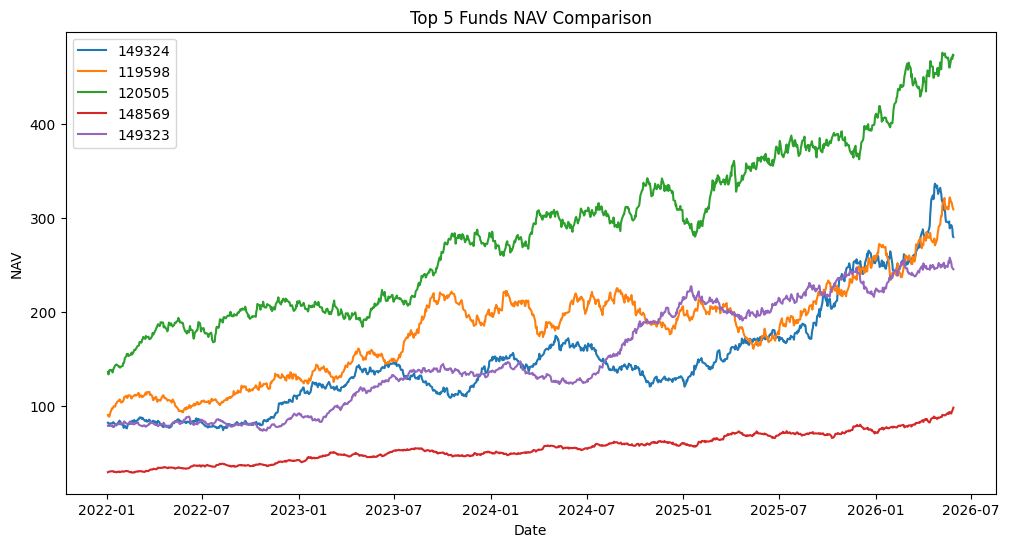

In [27]:
plt.figure(figsize=(12,6))

for code in top5["amfi_code"]:

    fund_data = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(code)
    )

plt.title("Top 5 Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.savefig(
    "../reports/benchmark_chart.png"
)

plt.show()